## Table 4: DeiT-Base model's results on CIFAR-10 dataset using A40 GPU

In [1]:
import numpy as np
import pandas as pd

In [ ]:
deit_base_data=[]
deit_base_data_test=[]

for i in range(1,101):
    temp1=[]
    for j in range(10):
        path='/home/rtx3060/Desktop/GPU_Trace/A40_new_Test/mem_csv_deit_base_a40/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    deit_base_data.append(temp1)

for i in range(1,31):
    temp1=[]
    for j in range(10):
        path='/home/rtx3060/Desktop/GPU_Trace/A40_new_Test/mem_csv_deit_base_test/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    deit_base_data_test.append(temp1)
    temp1=[]
  
print(deit_base_data[0][1].columns)
print(deit_base_data_test[0][1].columns)

Index(['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name',
       'Context', 'Stream', 'Block Size', 'Grid Size', 'Device',
       ...
       'smsp__sass_thread_inst_executed_op_fadd_pred_on.sum.per_cycle_elapsed',
       'smsp__sass_thread_inst_executed_op_ffma_pred_on.sum.per_cycle_elapsed',
       'smsp__sass_thread_inst_executed_op_fmul_pred_on.sum.per_cycle_elapsed',
       'smsp__thread_inst_executed_per_inst_executed.ratio',
       'smsp__thread_inst_executed_pred_on_per_inst_executed.ratio',
       'smsp__warps_active.avg.peak_sustained',
       'smsp__warps_active.avg.per_cycle_active',
       'smsp__warps_eligible.avg.per_cycle_active', 'thread_inst_executed',
       'thread_inst_executed_true'],
      dtype='object', length=802)
Index(['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name',
       'Context', 'Stream', 'Block Size', 'Grid Size', 'Device',
       ...
       'smsp__sass_thread_inst_executed_op_fadd_pred_on.sum.per_cycle_elapsed',
       'sms

### Section 2: Pre-processing Dataset

In [3]:
for i in range(100):
    for j in range(10):
        deit_base_data[i][j]=deit_base_data[i][j].drop(['ID'], axis=1)
        if 0 in deit_base_data[i][j].index:
            deit_base_data[i][j] = deit_base_data[i][j].drop(index=0)

for i in range(30):
    for j in range(10):
        deit_base_data_test[i][j]=deit_base_data_test[i][j].drop(['ID'], axis=1)
        if 0 in deit_base_data_test[i][j].index:
            deit_base_data_test[i][j] = deit_base_data_test[i][j].drop(index=0)

In [4]:
deit_base_data_test[0][0]['Kernel Name'].unique

<bound method Series.unique of 1     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
2     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
3     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
4     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
5     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
6     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
7     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
8     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
9     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
10    fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
11    fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
12    fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
Name: Kernel Name, dtype: object>

### Section 3: Metric-based Data filtering and pre-processing

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import random


kernel_name=['fmha_cutlassF_f32_aligned_64x64_rf_sm80']
ltx_cols=[col for col in deit_base_data[0][1].columns if 
    col.startswith('smsp__branch_targets_threads_divergent') #
        # or col.startswith('l1tex__data_bank_conflicts_pipe_lsu_mem_shared.sum') 
    #   or col.startswith('l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum') 
        # or col.startswith('sm__inst_executed_pipe_cbu_pred_on_any') 
        # or col.startswith('sm__mio_pq_read_cycles_active.sum') 
        # or col.startswith('sm__mio_pq_write_cycles_active.avg') 
        # col.startswith('l1tex__data_pipe_lsu_wavefronts_mem_shared_op_atom.sum') 
        # or col.startswith('smsp__thread') 
        # or col.startswith('smsp__average_warps_issue_stalled_branch_resolving_per_issue_active') 
        # or col.startswith('smsp__average_warps_issue_stalled_imc_miss_per_issue_active')# 
        # or col.startswith('smsp__average_warps_issue_stalled_misc_per_issue_active.ratio') 
        # or col.startswith('smsp__average_warps_issue_stalled_no_instruction_per_issue_active.ratio') 
        # or col.startswith('smsp__average_warps_issue_stalled_wait_per_issue_active.ratio') 
        or col.startswith('smsp__inst_executed.sum') 
        or col.startswith('smsp__inst_executed_op_branch') 
        or col.startswith('smsp__inst_executed_op_shared_atom') #
        or col.startswith('smsp__sass_branch_targets_threads_divergent') #
        or col.startswith('smsp__sass_inst_executed_op_shared_') 
        #  or col.startswith('smsp__sass_thread_inst_executed_op_fadd_pred_on.min') #
        # or col.startswith('smsp__sass_thread_inst_executed_op_ffma_pred_on.min') #
        # or col.startswith('smsp__sass_thread_inst_executed_op_fmul_pred_on.min') #
    # col.startswith('gpu__compute_memory_access_throughput_internal_actideity.max.pct_of_peak_sustained_elapsed') 
    # or col.startswith('gpu__compute_memory_access_throughput_internal_actideity.min.pct_of_peak_sustained_elapsed') 
    # or col.startswith('lts__d_sectors.max.pct_of_peak_sustained_elapsed')
    # or col.startswith('lts__d_sectors.min.pct_of_peak_sustained_elapsed') 
    # or col.startswith('thread_inst_executed')
    # or col.startswith('dram__bytes_read.sum')
    # or col.startswith('dram__bytes_write.sum')
    # or col.startswith('lts__t_sector_op_read_hit_rate.pct')
    # or col.startswith('fbpa__dram_sectors.max.pct_of_peak_sustained_elapsed')
    # or col.startswith('gpu__dram_throughput.max.pct_of_peak_sustained_elapsed')
    # or col.startswith('pcie__write_bytes.avg.per_second')
    # or col.startswith('sm__inst_executed_pipe_cbu_pred_on_any.max.pct_of_peak_sustained_elapsed') #
    # or col.startswith('sm__inst_executed_pipe_cbu_pred_on_any.min.pct_of_peak_sustained_elapsed') 
]
# ltx_cols.append('thread_inst_executed')
for col in ltx_cols:
    for i in range(100):
        for j in range(10):
            if deit_base_data[i][j][col].dtype == 'object':  # likely string
                deit_base_data[i][j][col] = pd.to_numeric(deit_base_data[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
    for i in range(30):
        for j in range(10):
            if deit_base_data_test[i][j][col].dtype == 'object':  # likely string
                deit_base_data_test[i][j][col] = pd.to_numeric(deit_base_data_test[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
               
# Optional: update the DataFrame back
print(ltx_cols)

['smsp__branch_targets_threads_divergent', 'smsp__inst_executed.sum', 'smsp__inst_executed_op_branch.sum', 'smsp__inst_executed_op_shared_atom.sum', 'smsp__inst_executed_op_shared_atom.sum.pct_of_peak_sustained_elapsed', 'smsp__sass_branch_targets_threads_divergent.avg', 'smsp__sass_inst_executed_op_shared_ld.sum', 'smsp__sass_inst_executed_op_shared_st.sum']


print(len(all_class_data))

In [49]:
deit_base_data[0][0].shape

(12, 801)

### Section 4: Generating classifier model's training data and validation data by considering only the filtered Metrics.

In [60]:
col = [col for col in deit_base_data[0][1].columns if 
    #    col.startswith('sass__') 
    # col.startswith('smsp__branch_targets_threads_divergent') #48
        # or col.startswith('l1tex__data_bank_conflicts_pipe_lsu_mem_shared.sum') #59.33
    #   or col.startswith('l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum') #52.67
        # or col.startswith('sm__inst_executed_pipe_cbu_pred_on_any.m') #0:10:65.33
        # or col.startswith('sm__inst_executed_pipe_cbu_pred_on_any.s')
        # or col.startswith('sm__mio_pq_read_cycles_active.sum') #57.67
        # or col.startswith('sm__mio_pq_write_cycles_active.avg.pct_of_peak_sustained_elapsed') #60.67
    #     or col.startswith('l1tex__data_pipe_lsu_wavefronts_mem_shared') #58.33
        # or col.startswith('smsp__thread') #59
    #    or col.startswith('smsp__average_warps_issue_stalled_branch_resolving_per_issue_active') #55.67
        # or col.startswith('smsp__average_warps_issue_stalled_imc_miss_per_issue_active') # 50.67
        # or col.startswith('smsp__average_warps_issue_stalled_misc_per_issue_active.ratio') #49.00
        # or col.startswith('smsp__average_warps_issue_stalled_no_instruction_per_issue_active.ratio') #56
        # or col.startswith('smsp__average_warps_issue_stalled_wait_per_issue_active.ratio') #56
       col.startswith('smsp__inst_executed.sum') #62
        or col.startswith('smsp__inst_executed_op_branch') #71.67
        or col.startswith('smsp__inst_executed_op_shared_atom') #71
        # or col.startswith('smsp__sass_branch_targets_threads_divergent') #
        or col.startswith('smsp__sass_inst_executed_op_shared_') #59
        #  or col.startswith('smsp__sass_thread_inst_executed_op_fadd_pred_on.min') #44.33
        # or col.startswith('smsp__sass_thread_inst_executed_op_ffma_pred_on.min') #44.33
        # or col.startswith('smsp__sass_thread_inst_executed_op_fmul_pred_on.min') #48
    # or col.startswith('gpu__compute_memory_access_throughput_internal_actideity.max.pct_of_peak_sustained_elapsed') #50
    # or col.startswith('gpu__compute_memory_access_throughput_internal_actideity.min.pct_of_peak_sustained_elapsed') #46.33
    # or col.startswith('lts__d_sectors.max.pct_of_peak_sustained_elapsed') #51.67
    # or col.startswith('lts__d_sectors.min.pct_of_peak_sustained_elapsed') 
    # or col.startswith('thread_inst_executed') #58
    # or col.startswith('dram__bytes_read.sum') #50.33
    # or col.startswith('dram__bytes_write.sum') #49.33
    # or col.startswith('lts__t_sector_op_read_hit_rate.pct') #49
    # or col.startswith('fbpa__dram_sectors.max.pct_of_peak_sustained_elapsed') #53
    # or col.startswith('gpu__dram_throughput.max.pct_of_peak_sustained_elapsed') #53.33
    # or col.startswith('pcie__write_bytes.avg.per_second') #49.67
    # or col.startswith('sm__inst_executed_pipe_cbu_pred_on_any.max.pct_of_peak_sustained_elapsed') #55.33
    # or col.startswith('sm__inst_executed_pipe_cbu_pred_on_any.min.pct_of_peak_sustained_elapsed') #51.33
    # or col.startswith('l1tex__m_l1tex2xbar_write_bytes.sum')
]

for i in range(100):
    for j in range(10):
        for c in col:
            deit_base_data[i][j][c]=pd.to_numeric(deit_base_data[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
            
for i in range(30):
    for j in range(10):
        for c in col:
            deit_base_data_test[i][j][c]=pd.to_numeric(deit_base_data_test[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
            


# Loop through each DataFrame and keep only the selected columns (if they exist)
deit_base_data_df=[[[] for i in range(10)] for j in range(100)]
deit_base_data_test_df=[[[] for i in range(10)] for j in range(30)]

for i in range(len(deit_base_data)):
    for j in range(len(deit_base_data[i])):
        df2 = deit_base_data[i][j]
        # Keep only the columns that exist in the current DataFrame
        selected_cols = [c for c in col if c in df2.columns]
        deit_base_data_df[i][j] = deit_base_data[i][j][selected_cols].copy()
        
for i in range(len(deit_base_data_test)):
    for j in range(len(deit_base_data_test[i])):
        df2 = deit_base_data_test[i][j]
        # Keep only the columns that exist in the current DataFrame
        selected_cols = [c for c in col if c in df2.columns]
        deit_base_data_test_df[i][j] = df2[selected_cols].copy()

In [61]:
print(col)

['smsp__inst_executed.sum', 'smsp__inst_executed_op_branch.sum', 'smsp__inst_executed_op_shared_atom.sum', 'smsp__inst_executed_op_shared_atom.sum.pct_of_peak_sustained_elapsed', 'smsp__sass_inst_executed_op_shared_ld.sum', 'smsp__sass_inst_executed_op_shared_st.sum']


In [62]:
deit_base_data_df[0][0].shape

(12, 6)

### Dataset re-arrangement and providing label for training and test samples for both shadow and target model. Also, selecting appropiate range of FMHA kernel instances for achieving maximum attack success rate.

In [63]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train=[]
y_train=[]
X_test=[]
y_test=[]

for i in range(100):
    for j in range(10):
        r = deit_base_data_df[i][j]  # shape: (12, 2)
        j_col = np.full((r.shape[0], 1), j)  # shape: (12, 1)
        r_with_class = np.concatenate([r, j_col], axis=1)  # shape: (12, 3)
        X_train.append(r_with_class)

        if i < 50:
            y_train.append(1)
        else:
            y_train.append(0)

for i in range(30):
    for j in range(10):
        r = deit_base_data_test_df[i][j]  # shape: (12, 2)
        j_col = np.full((r.shape[0], 1), j)
        r_with_class = np.concatenate([r, j_col], axis=1)
        X_test.append(r_with_class)

        if i < 15:
            y_test.append(1)
        else:
            y_test.append(0)


X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

X_train = X_train[:, 0:6, :]
X_test = X_test[:, 0:6, :]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1000, 6, 7) (1000,)
(300, 6, 7) (300,)


In [64]:
import numpy as np
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([500, 500]))
(array([0, 1]), array([150, 150]))


In [65]:
from tensorflow.keras.utils import to_categorical

### Attack Classifier training

In [66]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization
import numpy as np
from sklearn.model_selection import train_test_split

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  
def reset_random_seeds():
   os.environ['PYTHONHASHSEED']=str(42)
   tf.random.set_seed(42)
   np.random.seed(42)
   random.seed(42)

reset_random_seeds()
import tensorflow as tf

# Your input data shape: (samples, sequence_length, feature_dim)
num_samples = X_train.shape[0]
sequence_length = X_train.shape[1]
feature_dim = X_train.shape[2]

# Define the model
# Stacked BiLSTM Layers
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(sequence_length, feature_dim)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(32, return_sequences=False)))
model.add(Dropout(0.2))

# Fully connected hidden layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))


# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Separate features and class column
features_train = X_train[:, :, :-1]  
class_train = X_train[:, :, -1:]    
mean = features_train.mean(axis=(0, 1), keepdims=True)
std = features_train.std(axis=(0, 1), keepdims=True)
features_train = (features_train - mean) / (std + 1e-8)
X_train = np.concatenate([features_train, class_train], axis=-1)

# Summary
model.summary()
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
# Train
history = model.fit(
    X_train_split, y_train_split,
    epochs=200,
    batch_size=45,
    validation_data=(X_val_split, y_val_split)
)

/home/rtx3060/.local/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_12                │ (None, 6, 128)         │        36,864 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,305 (321.50 KB)

 Trainable params: 82,305 (321.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5093 - loss: 0.6958 - val_accuracy: 0.4700 - val_loss: 0.6979
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4769 - loss: 0.6979 - val_accuracy: 0.5300 - val_loss: 0.6943
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5098 - loss: 0.6913 - val_accuracy: 0.5300 - val_loss: 0.6956
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5192 - loss: 0.6893 - val_accuracy: 0.5550 - val_loss: 0.6947
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5373 - loss: 0.6859 - val_accuracy: 0.5350 - val_loss: 0.6932
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5360 - loss: 0.6875 - val_accuracy: 0.6050 - val_loss: 0.6910
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5656 - loss: 0.6817 - val_accuracy: 0.5750 - val_loss: 0.6881
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5400 - loss: 0.6809 - val_accuracy: 0.5950 - 

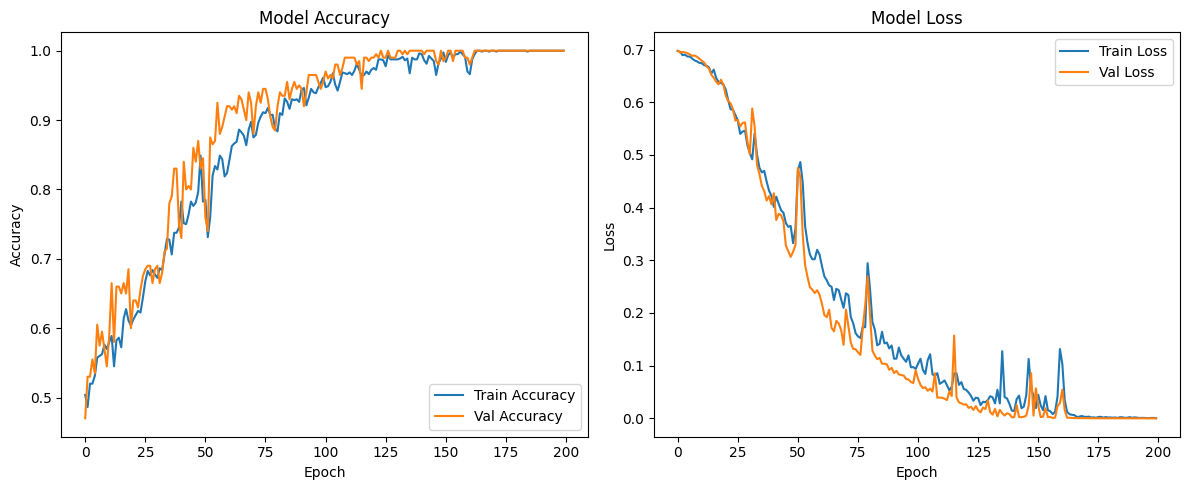

In [67]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


### Membership Inference Attack on Target Model Data

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Test Accuracy: 0.9067
Confusion Matrix:
 [[138  12]
 [ 16 134]]


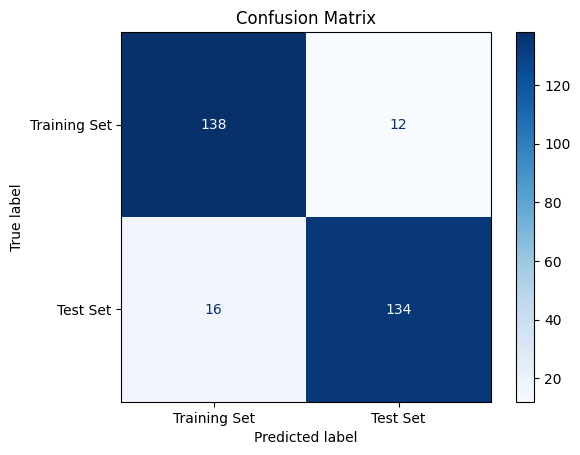

In [68]:
# Predict
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


features_test = X_test[:, :, :-1] 
class_test = X_test[:, :, -1:]    
mean = features_test.mean(axis=(0, 1), keepdims=True)
std = features_test.std(axis=(0, 1), keepdims=True)
features_test = (features_test - mean) / (std + 1e-8)
X_test = np.concatenate([features_test, class_test], axis=-1)

# Predict probabilities
predictions = model.predict(X_test)

# # Convert probabilities to binary labels
predicted_labels = (predictions > 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, predicted_labels)
print(f"Test Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, predicted_labels)
print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Training Set", "Test Set"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()



F1 Score: 0.9054
AUC Score: 0.9610


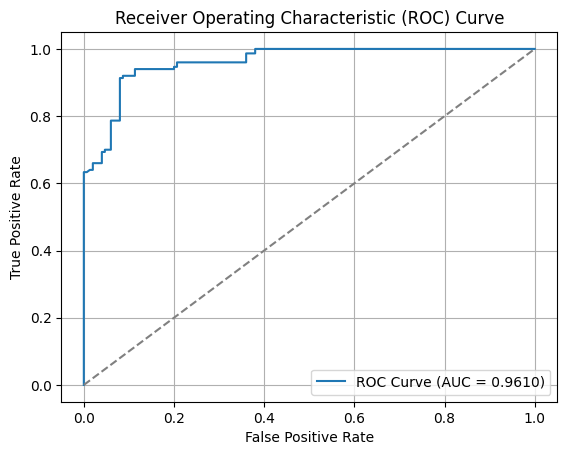

TPR at FPR <= 0.01: 0.6333


In [69]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np

# Binary predictions using threshold 0.5
predicted_labels = (predictions >= 0.5).astype(int)

# F1 Score
f1 = f1_score(y_test, predicted_labels)
print(f"F1 Score: {f1:.4f}")

# AUC Score
auc_score = roc_auc_score(y_test, predictions)
print(f"AUC Score: {auc_score:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predictions)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# TPR at low FPR (e.g., FPR <= 0.01)
threshold_fpr = 0.01
low_fpr_indices = np.where(fpr <= threshold_fpr)[0]

if len(low_fpr_indices) > 0:
    tpr_at_low_fpr = tpr[low_fpr_indices[-1]]
    print(f"TPR at FPR <= {threshold_fpr:.2f}: {tpr_at_low_fpr:.4f}")
else:
    print(f"No FPR <= {threshold_fpr:.2f} found in ROC data.")
